In [4]:
import os
import sys
import re
import bibtexparser
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_unweighted
import matplotlib as mpl
import seaborn as sbs
import networkx as nx
import pybliometrics
from pybliometrics.scopus import ScopusSearch, AbstractRetrieval
from tqdm import tqdm
import time
import csv
import pickle
import os
from os import listdir
from datetime import datetime
import requests

custom_colors =['#D62A28','#6AD376','#9FDAE5']#'#2278B5']
legend_labels= ['Robotic Deconstruction of the Built Environment','Robotic Disassembly','Construction Robotics']

In [5]:
topic_dfs = {}
topic_set_labels = {
              'dec_rob':'Robotic Disassembly',
              'rob_be':'Construction Robotics',
              'dec_rob_be':'Robotic Deconstruction of the Built Environment'}
topic_csvs = [
    'dec_rob_prel_screened',
    'rob_be_prel_screened', 
    'dec_rob_be_prel_screened']

for csv in topic_csvs:
    folder_name = 'HTDaA_SLR_screening/preliminary_screened/'
    extra_str= '.csv'
    df = pd.read_csv(folder_name + csv+extra_str)
    print(topic_set_labels[csv[:-14]])
    exclusion_mask = ((df['Ad_Rob_Imp']==0) & (df['Res_Decon']==0) & (df['Direct_App']==0))
    excluded_df = df[exclusion_mask]
    included_df = df[~ exclusion_mask]
    included_df['Group'] = included_df['rev_task'].str[4:]
    print(f'{len(excluded_df)} excluded from {len(included_df)+len(excluded_df)}')
    topic_dfs[csv[:-14]]= included_df.copy()
    print(f"Set has {len(topic_dfs[csv[:-14]])} documents")
    
rows_to_move = {topic:[] for topic in topic_dfs}

for topic,df in topic_dfs.items():
    target_topics = df['rev_task'].str[4:]
    misplaced = df[target_topics!=topic]
    topic_dfs[topic] = df[target_topics == topic].copy()

    for target_topic, group in misplaced.groupby(target_topics[target_topics != topic]):
        rows_to_move[target_topic].append(group)

for target_topic, dfs in rows_to_move.items():
    if dfs:
        topic_dfs[target_topic] = pd.concat(
            [topic_dfs[target_topic], *dfs],
            ignore_index=True
        )

for topic in topic_dfs:
    print(f"Reassigned {topic_set_labels[topic]}: {len(topic_dfs[topic])}")

Robotic Disassembly
1253 excluded from 1769
Set has 516 documents
Construction Robotics
1089 excluded from 1332
Set has 243 documents
Robotic Deconstruction of the Built Environment
24 excluded from 35
Set has 11 documents
Reassigned Robotic Disassembly: 496
Reassigned Construction Robotics: 243
Reassigned Robotic Deconstruction of the Built Environment: 31


C:\Users\Owner\AppData\Local\Temp\ipykernel_41572\1504427013.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  included_df['Group'] = included_df['rev_task'].str[4:]
C:\Users\Owner\AppData\Local\Temp\ipykernel_41572\1504427013.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  included_df['Group'] = included_df['rev_task'].str[4:]
C:\Users\Owner\AppData\Local\Temp\ipykernel_41572\1504427013.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

In [6]:
combined_ = pd.concat(topic_dfs.values(),ignore_index=True)
print(f"The combined dataset has {len(combined_)} entries")
### Double-check no duplicates
vendupes_by_id = combined_[combined_.duplicated('title',keep=False)].sort_values('title')
print(f"There are {len(combined_)-len(combined_.drop_duplicates(subset=['title']).copy())} duplicates")

The combined dataset has 770 entries
There are 0 duplicates


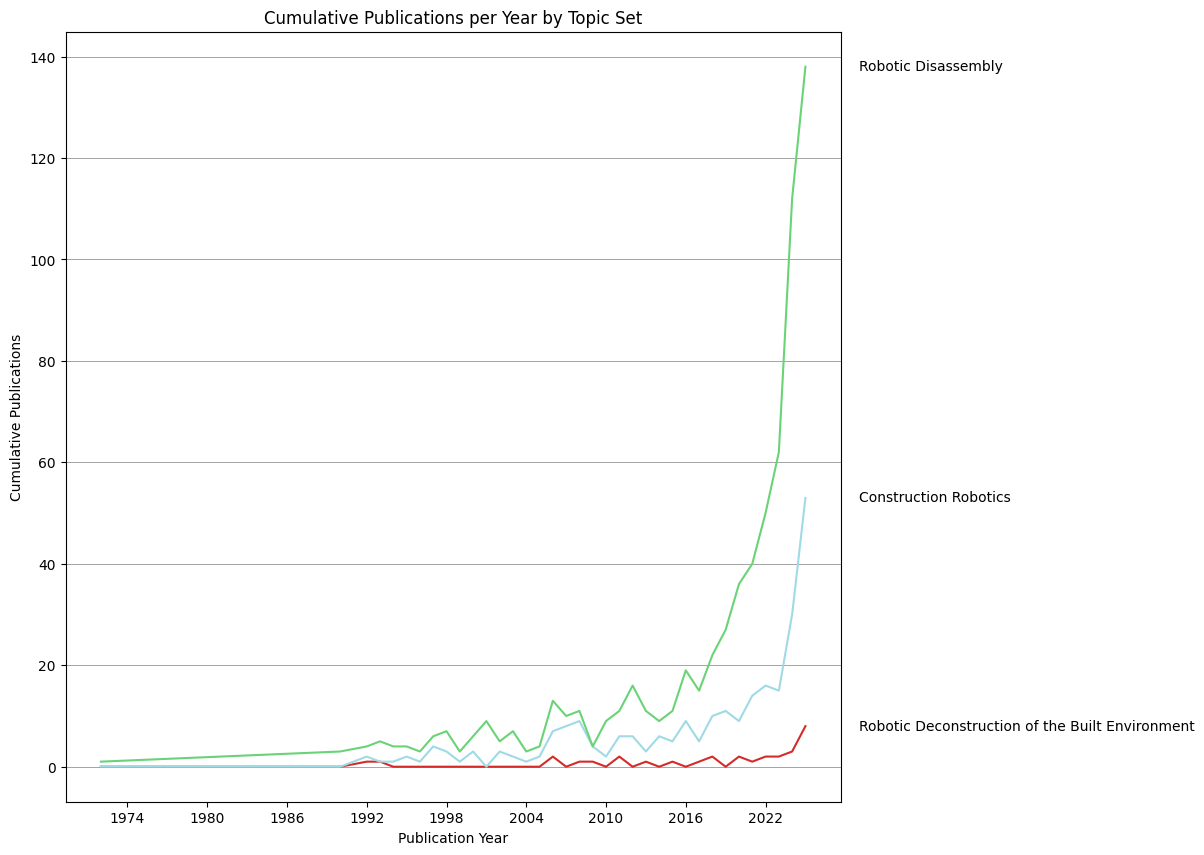

In [60]:
from matplotlib.ticker import MaxNLocator
ax = plt.figure(figsize=(10,10)).gca()

all_counts  = {}
# for i,file in enumerate(query_csvs):
for group_name, group_df in combined_.groupby('Group'):
    counts = group_df["year"].value_counts().sort_index()
    all_counts[group_name] = counts

    counts = group_df['year'].value_counts().sort_index()
    label = group_name

    all_counts[label] = counts
   
combined_yearly = pd.concat(all_counts,axis=1).fillna(0).astype(int)
combined_yearly = combined_yearly.sort_index()

group_order = combined_yearly.sum().sort_values().index
combined_yearly = combined_yearly[group_order]


cumulative_yearly = combined_yearly.cumsum(axis=1)
for i,col in enumerate(combined_yearly.columns):
    line1, = ax.plot(cumulative_yearly.index.astype(int)[:-1],cumulative_yearly[col].astype(int)[:-1],label=topic_set_labels[col],
            color=custom_colors[legend_labels.index(topic_set_labels[col])])
    ax.annotate(topic_set_labels[col], 
            xy=(line1.get_xdata()[-1], line1.get_ydata()[-1]),
            xytext=(line1.get_xdata()[-1] + 4, line1.get_ydata()[-1]), 
            textcoords='data',
            ha='left', va='center',)
    
ax.grid(axis='y', color='grey', linewidth=0.5)
ax.patch.set_facecolor('white')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Publication Year")
ax.set_ylabel("Cumulative Publications")
ax.set_title("Cumulative Publications per Year by Topic Set")
plt.savefig('HTDaA_SLR_Corpus_Plots/Publications_By_Year.svg')

In [61]:
item_type_map = {
    # conference papers / proceedings
    r'.*\bPROCEEDINGS?\b.*': 'Conference paper',
    r'.*\bCONFERENCES\b.*': 'Conference paper',
    r'.*\bCONFERENCE\b.*': 'Conference paper',
    r'.*\bCONFERENCE PAPER\b.*': 'Conference paper',
    r'.*\bINPROCEEDINGS\b.*': 'Conference paper',
    r'.*\bCONF\b.*': 'Conference paper',

    # articles
    r'.*\bARTICLE\b.*': 'Article',
    r'.*\bJOURNALS\b.*': 'Article',
    r'.*\bJOURNAL ARTICLE\b.*': 'Article',
    r'.*\bRESEARCH ARTICLE\b.*': 'Article',
    r'.*\bREVIEW ARTICLE\b.*': 'Article',

    # book sections
    r'.*\bBOOK SECTION\b.*': 'Book section',
    r'.*\bBOOK CHAPTER\b.*': 'Book section',
    r'.*\bCHAPTER\b.*': 'Book section',
    r'.*\bINBOOK\b.*': 'Book section',
    r'.*\bINCOLLECTION\b.*': 'Book section',
}

def normalize_item_type(v):
    if pd.isna(v):
        return v

    v_upper = str(v).upper().strip()

    for pattern, canonical in item_type_map.items():
        if re.match(pattern, v_upper, flags=re.IGNORECASE):
            return canonical

    return v

combined_['item_type'] = (
    combined_['item_type']
    .apply(normalize_item_type)
)



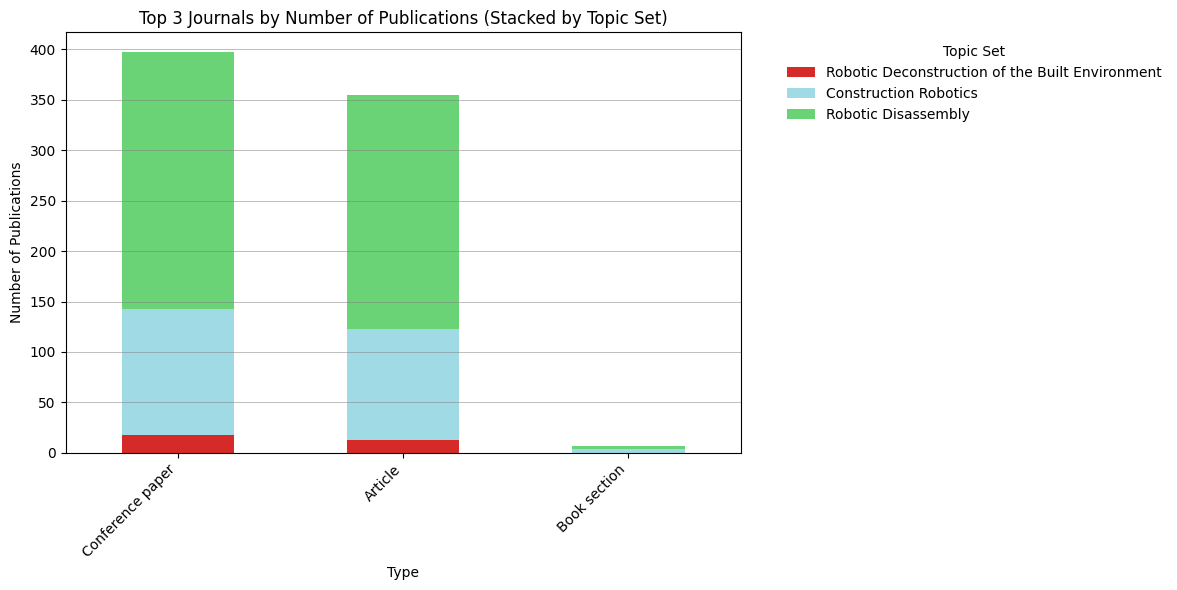

In [62]:
journal_counts = {}
for group_name,group_df in combined_.groupby('Group'):
    # df = pd.read_csv(file)
    group_df['item_type'] = group_df['item_type'].fillna("Unknown").astype(str).str.strip()
    counts = group_df['item_type'].value_counts()
    journal_counts[topic_set_labels[group_name]]=counts

combined_df = pd.concat(journal_counts, axis=1).fillna(0).astype(int)
TOP_N = 3
top_journals = combined_df.sum(axis=1).sort_values(ascending=False).head(TOP_N).index
combined_df = combined_df.loc[top_journals]
group_order = combined_df.sum().sort_values().index
combined_df = combined_df[group_order]
ordered_colors = [custom_colors[legend_labels.index(go)] for go in group_order]
ax = combined_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=ordered_colors,
    
)
ax.grid(axis="y", alpha=0.7)
ax.figure.set_facecolor("#ffffff")
plt.title(f"Top {TOP_N} Journals by Number of Publications (Stacked by Topic Set)")
plt.xlabel("Type")
ax.grid(axis='y', color='grey', linewidth=0.5)

ax.patch.set_facecolor('white')
plt.ylabel("Number of Publications")
plt.legend(title="Topic Set", bbox_to_anchor=(1.05, 1), loc="upper left",framealpha=0.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("HTDaA_SLR_Corpus_Plots/Paper_Types.svg", dpi=300, bbox_inches="tight")
plt.show()


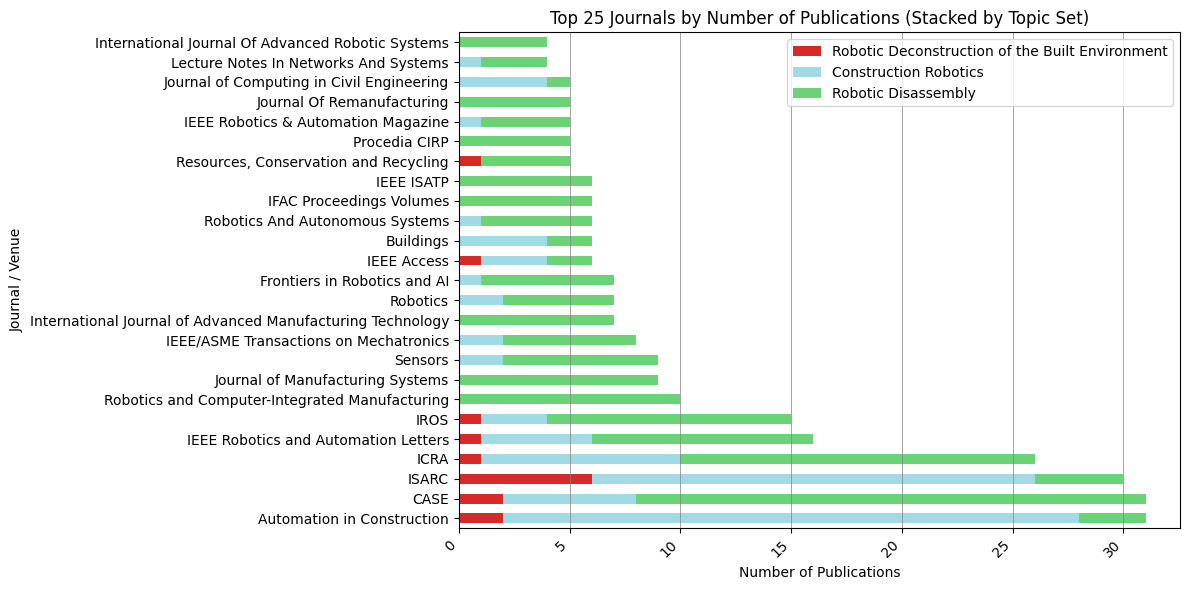

In [63]:
venue_map = {
    r'.*\bISARC\b.*': 'ISARC',
    r'.*AUTOMATION AND ROBOTICS IN CONSTRUCTION.*': 'ISARC',

    r'.*\bICRA\b.*': 'ICRA',
    r'.*INTERNATIONAL CONFERENCE ON ROBOTICS AND AUTOMATION.*': 'ICRA',

    r'.*\bIROS\b.*': 'IROS',
    r'.*INTELLIGENT ROBOTS AND SYSTEMS.*': 'IROS',

    r'.*\bCASE\b.*': 'CASE',
    r'.*AUTOMATION SCIENCE AND ENGINEERING.*': 'CASE',

    r'.*ASSEMBLY AND TASK PLANNING.*': 'IEEE ISATP',

    r'.*ROBOTICS AND AUTOMATION LETTERS.*': 'IEEE Robotics and Automation Letters',
    r'.*TRANSACTIONS ON AUTOMATION SCIENCE AND ENGINEERING.*': 'IEEE Transactions on Automation Science and Engineering',
    r'.*TRANSACTIONS ON MECHATRONICS.*': 'IEEE/ASME Transactions on Mechatronics',
    r'.*ROBOTICS\s*&\s*AUTOMATION MAGAZINE.*': 'IEEE Robotics & Automation Magazine',

    r'.*AUTOMATION IN CONSTRUCTION.*': 'Automation in Construction',
    r'.*ROBOTICS AND COMPUTER[- ]INTEGRATED MANUFACTURING.*': 'Robotics and Computer-Integrated Manufacturing',
    r'.*JOURNAL OF MANUFACTURING SYSTEMS.*': 'Journal of Manufacturing Systems',
    r'.*INTERNATIONAL JOURNAL OF ADVANCED MANUFACTURING TECHNOLOGY.*': 'International Journal of Advanced Manufacturing Technology',
    r'.*JOURNAL OF COMPUTING IN CIVIL ENGINEERING.*': 'Journal of Computing in Civil Engineering',
    r'.*FRONTIERS IN ROBOTICS AND AI.*': 'Frontiers in Robotics and AI',
    r'.*IEEE ACCESS.*': 'IEEE Access',
    r'.*PROCEDIA CIRP.*': 'Procedia CIRP',
    r'.*IFAC PROCEEDINGS.*': 'IFAC Proceedings Volumes',
    r'.*IFAC PAPERSONLINE.*': 'IFAC-PapersOnLine',
    r'.*RESOURCES CONSERVATION AND RECYCLING.*': 'Resources, Conservation and Recycling',

    r'^SENSORS$': 'Sensors',
    r'^BUILDINGS$': 'Buildings',
    r'^ROBOTICS$': 'Robotics',
}

def normalize_venue(v):
    if pd.isna(v):
        return "Unknown"

    v_clean = str(v).strip()
    v_upper = v_clean.upper()

    for pattern, canonical in venue_map.items():
        if re.match(pattern, v_upper, flags=re.IGNORECASE):
            return canonical

    return v_clean.title()


combined_ = combined_.copy()
combined_['journal_or_venue'] = combined_['journal_or_venue'].apply(normalize_venue)

journal_counts = {}

for group_name, group_df in combined_.groupby('Group'):
    counts = group_df['journal_or_venue'].value_counts()
    journal_counts[topic_set_labels[group_name]] = counts

combined_df = pd.concat(journal_counts, axis=1).fillna(0).astype(int)

TOP_N = 25
top_journals = combined_df.sum(axis=1).sort_values(ascending=False).head(TOP_N).index
combined_df = combined_df.loc[top_journals]

group_order = combined_df.sum().sort_values().index
combined_df = combined_df[group_order]

ordered_colors = [
    custom_colors[legend_labels.index(go)]
    for go in group_order
]

ax = combined_df.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 6),
    color=ordered_colors, 
)
# ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.figure.set_facecolor("#ffffff")
plt.title(f"Top {TOP_N} Journals by Number of Publications (Stacked by Topic Set)")
plt.xlabel("Number of Publications")
ax.grid(axis='x', color='grey', linewidth=0.5)

ax.patch.set_facecolor('white')
plt.ylabel("Journal / Venue")
# plt.legend(title="Research Area", bbox_to_anchor=(1.05, 1), loc="upper left",framealpha=0.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("HTDaA_SLR_Corpus_Plots/Top_Venues.svg", dpi=300, bbox_inches="tight")
plt.show()

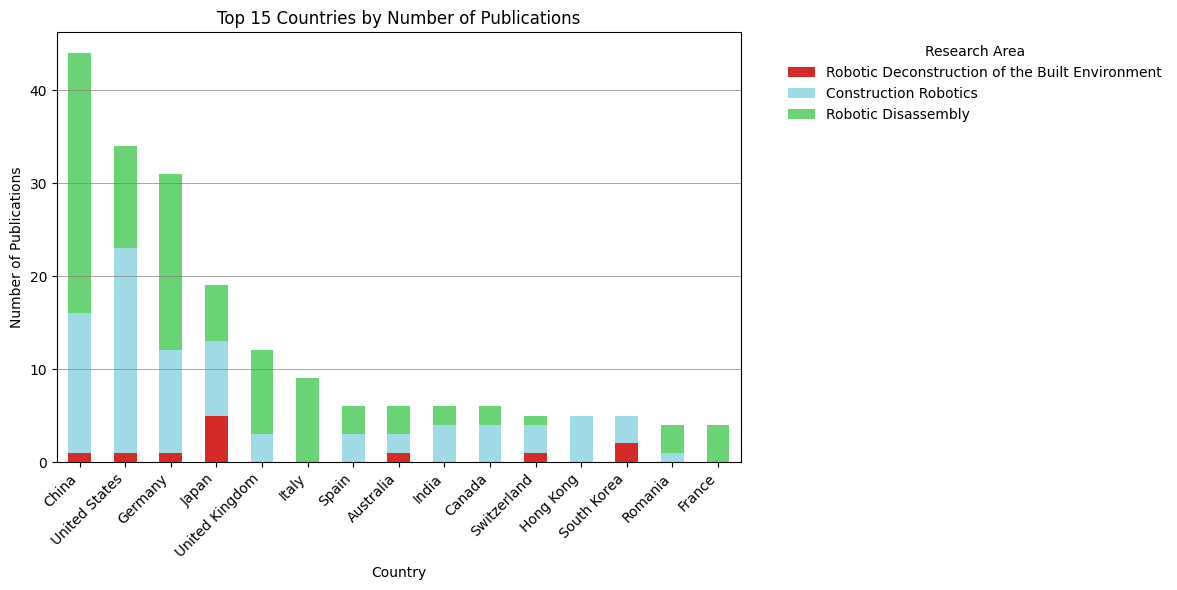

In [64]:
from collections import Counter

def dominant_country(s):
    if pd.isna(s):
        return None

    countries = [c.strip() for c in str(s).split(';') if c.strip()]

    if not countries:
        return None

    return Counter(countries).most_common(1)[0][0]


def max_country_count(s):
    if pd.isna(s):
        return 0

    countries = [c.strip() for c in str(s).split(';') if c.strip()]

    if not countries:
        return 0

    return Counter(countries).most_common(1)[0][1]


combined_ = combined_.copy()

combined_['dominant_affiliation_country'] = (
    combined_['affiliation_country']
    .apply(dominant_country)
)

combined_['max_country_count'] = (
    combined_['affiliation_country']
    .apply(max_country_count)
)

country_counts = {}

for group_name, group_df in combined_.groupby('Group'):
    counts = group_df['dominant_affiliation_country'].value_counts()
    country_counts[topic_set_labels[group_name]] = counts

combined_country = (
    pd.concat(country_counts, axis=1)
    .fillna(0)
    .astype(int)
)

TOP_N = 15

top_countries = (
    combined_country
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

combined_top_country = combined_country.loc[top_countries]

group_order = combined_top_country.sum(axis=0).sort_values().index
combined_top_country = combined_top_country[group_order]

ordered_colors = [
    custom_colors[legend_labels.index(go)]
    for go in group_order
]

fig, ax = plt.subplots(figsize=(12, 6))

combined_top_country.plot(
    kind='bar',
    stacked=True,
    color=ordered_colors,
    ax=ax
)

ax.figure.set_facecolor("#ffffff")
ax.patch.set_facecolor("white")

ax.grid(axis='y', color='grey', linewidth=0.5)

plt.title(f"Top {TOP_N} Countries by Number of Publications")
plt.xlabel("Country")
plt.ylabel("Number of Publications")

plt.legend(
    title="Research Area",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    framealpha=0.0
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("HTDaA_SLR_Corpus_Plots/Countries.svg", dpi=300, bbox_inches="tight")
plt.show()

In [2]:

score_cols = ['Ad_Rob_Imp', 'Res_Decon', 'Direct_App']

combined_ = combined_.copy()

combined_[score_cols] = (
    combined_[score_cols]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

combined_['transferability_score'] = combined_[score_cols].sum(axis=1).astype(int)

score_counts = {}

for group_name, group_df in combined_.groupby('Group'):
    counts = group_df['transferability_score'].value_counts().sort_index()
    score_counts[topic_set_labels[group_name]] = counts

combined_score = (
    pd.concat(score_counts, axis=1)
    .fillna(0)
    .astype(int)
)

combined_score = combined_score.reindex([1, 2, 3], fill_value=0)

group_order = combined_score.sum(axis=0).sort_values().index
combined_score = combined_score[group_order]

ordered_colors = [
    custom_colors[legend_labels.index(go)]
    for go in group_order
]

fig, ax = plt.subplots(figsize=(8, 6))

combined_score.plot(
    kind='bar',
    stacked=True,
    color=ordered_colors,
    ax=ax
)

ax.figure.set_facecolor("#ffffff")
ax.patch.set_facecolor("white")

ax.grid(axis='y', color='grey', linewidth=0.5)

plt.title("Transferability Score Distribution by Research Area")
plt.xlabel("Transferability Score")
plt.ylabel("Number of Publications")

plt.xticks(rotation=0)

plt.legend(
    title="Research Area",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    framealpha=0.0
)

plt.tight_layout()
plt.savefig("HTDaA_SLR_Corpus_Plots/Transferability_Score_Distribution_by_Research_Area.svg", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'combined_' is not defined

In [1]:

score_labels = {
    'Ad_Rob_Imp': 'Robotic Implementation',
    'Res_Decon': 'On-site Constraints',
    'Direct_App': 'Direct Application'
}

combined_ = combined_.copy()

combined_[score_cols] = (
    combined_[score_cols]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
)

plot_counts = {}

for col in score_cols:
    for val in [1, 0]:
        label = f"{score_labels[col]} = {val}"

        counts = (
            combined_[combined_[col] == val]
            .groupby('Group')
            .size()
        )

        plot_counts[label] = counts

plot_df = (
    pd.DataFrame(plot_counts)
    .T
    .fillna(0)
    .astype(int)
)

plot_df.columns = [
    topic_set_labels[g] for g in plot_df.columns
]

group_order = plot_df.sum(axis=0).sort_values().index
plot_df = plot_df[group_order]

ordered_colors = [
    custom_colors[legend_labels.index(go)]
    for go in group_order
]

fig, ax = plt.subplots(figsize=(11, 6))

plot_df.plot(
    kind='bar',
    stacked=True,
    color=ordered_colors,
    ax=ax
)

ax.figure.set_facecolor("#ffffff")
ax.patch.set_facecolor("white")

ax.grid(axis='y', color='grey', linewidth=0.5)

plt.title("Transferability Criteria Presence by Research Area")
plt.xlabel("Transferability Criterion")
plt.ylabel("Number of Publications")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Research Area",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    framealpha=0.0
)

plt.tight_layout()
plt.savefig("HTDaA_SLR_Corpus_Plots/Transferability_Criteria_by_Research_Area.svg", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'combined_' is not defined